In [3]:
#!/usr/bin/env python
"""
grid_search_C2v_15272.py

Coarse grid evaluation of chi^2 for DIB 15272, C2v symmetry.

User-facing rotational constant convention (A is the dominant C2-axis constant):
    pgopher_C (largest) = A
    pgopher_B           = B_f * A
    pgopher_A (smallest)= C_f * A

Fixed parameters:
    frac_A = frac_B = frac_C = 0.99
    lorentz_width (tau)       = 0.7 cm^-1
    center_offset              = 0.0 cm^-1

Grids:
    T    = [5, 10, 15, 20]
    A    = [0.001, 0.003, 0.01, 0.03, 0.1]
    B_f  = [0.9, 0.5, 0.1]
    C_f  = [0.9, 0.5, 0.1]

Combinations where B_f <= C_f violate pgopher_B > pgopher_A and are skipped.

Saves chi2_direct, chi2_dT, chi2_total and the grid coords to
grid_search_C2v_15272.npz in the repo root.
"""

import os, shutil, subprocess, itertools
import numpy as np
import h5py
from pathlib import Path
from scipy.signal import convolve
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

In [ ]:
# REPO_ROOT = Path(__file__).resolve().parent

REPO_ROOT = os.path.expanduser('~/DIB/')

# ── Constants ──────────────────────────────────────────────────────────────────
CENTRAL_INVCM = 1e8 / 15272.27178113337   # ~6544.44 cm^-1
LSF_FILE     = str(REPO_ROOT + '/LSFs'     + '/lsf_15272.h5')
DATA_FILE    = str(REPO_ROOT + '/all_errs' + '/res_dib_15272.h5')
PGO_TEMPLATE = str(REPO_ROOT + '/pgo_files' + '/asym_top_15272_C2v.pgo')
PGO_BIN      = str(REPO_ROOT + '/pgo')

CROP  = 15    # default err_model crop for 15272
FUDGE = 1.0   # noise inflation on direct spectrum

FRAC_A = FRAC_B = FRAC_C = 0.99
TAU       = 0.7
DELTA_CEN = 0.0

# ── Grid definition ────────────────────────────────────────────────────────────
T_grid  = [5, 10, 15, 40]
A_grid  = [0.005, 0.01, 0.025, 0.07, 0.1]
Bf_grid = [0.9, 0.7, 0.5, 0.3, 0.1]
Cf_grid = [0.9, 0.5, 0.1]

# ── Temp directory ─────────────────────────────────────────────────────────────
TEMP_DIR = os.path.expanduser(
    '~/../../scratch/gpfs/MELCHIOR/cj1223/DIB/pgo_temppy_grid_C2v_15272')
shutil.rmtree(TEMP_DIR, ignore_errors=True)
os.makedirs(TEMP_DIR)

# ── Data loading ───────────────────────────────────────────────────────────────
with h5py.File(DATA_FILE, 'r') as df:
    data_wavelength = df['wav'][:]
    data_flux       = df['mean'][:, 0]
    data_flux_dT    = df['mean'][:, 1]
    noise_std       = FUDGE * np.sqrt(df['var'][:, 0])
    noise_std_dT    =         np.sqrt(df['var'][:, 1])

with h5py.File(LSF_FILE, 'r') as f:
    wav_grid = f['wav'][:]

# ── PGOPHER call ───────────────────────────────────────────────────────────────
def run_pgopher(T, pgopher_A, pgopher_B, pgopher_C):
    """
    Run PGOPHER for C2v 15272 and return LSF-convolved flux on the data wavelength grid.

    Parameters follow PGOPHER C2v 15272 convention: pgopher_C > pgopher_B > pgopher_A.
    The excited-state constants are scaled by FRAC_* (fixed at 0.99).
    """
    A_e = pgopher_A * FRAC_A
    B_e = pgopher_B * FRAC_B
    C_e = pgopher_C * FRAC_C

    tag = (f"T{T:.4f}_A{pgopher_A:.7f}_B{pgopher_B:.7f}_C{pgopher_C:.7f}")
    pgo_file = os.path.join(TEMP_DIR, f"temp_{tag}.pgo")
    spec_txt = os.path.join(TEMP_DIR, f"spec_{tag}.txt")

    awk = f'''awk \
  -v temp="{T}" \
  -v A_ground="{pgopher_A}" -v B_ground="{pgopher_B}" -v C_ground="{pgopher_C}" \
  -v A_excited="{A_e}"      -v B_excited="{B_e}"      -v C_excited="{C_e}" \
  -v lorentz_width="{TAU}" '
BEGIN {{ in_ground=0; in_excited=0; }}
/<AsymmetricTop Name="v=0"/  {{ in_ground=1; }}
/<AsymmetricTop Name="v=1"/  {{ in_excited=1; }}
/<\\/AsymmetricTop>/          {{ in_ground=0; in_excited=0; }}
in_ground  && /<Parameter Name="A" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" A_ground "\\"") }}
in_ground  && /<Parameter Name="B" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" B_ground "\\"") }}
in_ground  && /<Parameter Name="C" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" C_ground "\\"") }}
in_excited && /<Parameter Name="A" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" A_excited "\\"") }}
in_excited && /<Parameter Name="B" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" B_excited "\\"") }}
in_excited && /<Parameter Name="C" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" C_excited "\\"") }}
/<CartesianTransitionMoment Bra="v=1" Ket="v=0"/ {{ sub(/Axis="[^"]+"/, "Axis=\\"a\\"") }}
/<Parameter Name="Temperature" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" temp "\\"") }}
/<Parameter Name="Lorentzian"  Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" lorentz_width "\\"") }}
{{ print }}
' {PGO_TEMPLATE} > {pgo_file}'''

    subprocess.run(awk, shell=True, check=True, executable='/bin/bash')
    subprocess.run([PGO_BIN, '--plot', pgo_file, spec_txt],
                   check=True, stdout=subprocess.DEVNULL)

    inv_cm, flux = np.loadtxt(spec_txt).T
    wav_pgo = 1e8 / inv_cm

    # Convolve with three-Gaussian APOGEE LSF
    wavc   = 1e8 / CENTRAL_INVCM
    window, dlam = 8.0, 0.01
    wav_reg = np.arange(wavc - window, wavc + window, dlam)
    flux_reg = interp1d(wav_pgo, flux, bounds_error=False, fill_value=0.0)(wav_reg)

    sig1, sig2, sig3 = 0.3, 1.85 * 0.3, 9.5 * 0.3
    f1, f2, c0 = 0.895, 0.1, 1.3e-3
    rel = wav_reg - wavc
    lsf  = (f1 / np.sqrt(2*np.pi*sig1**2) * np.exp(-rel**2 / (2*sig1**2))
           + f2 / np.sqrt(2*np.pi*sig2**2) * np.exp(-rel**2 / (2*sig2**2))
           + (1-f1-f2) / np.sqrt(2*np.pi*sig3**2) * np.exp(-rel**2 / (2*sig3**2))
           + c0)
    lsf /= lsf.sum()
    convolved = convolve(flux_reg, lsf, mode='same')
    flux_on_grid = interp1d(wav_reg, convolved, bounds_error=False, fill_value=0.0)(wav_grid)

    os.remove(spec_txt)
    os.remove(pgo_file)
    return flux_on_grid


# ── chi^2 evaluation ───────────────────────────────────────────────────────────
def eval_chi2(flux, flux_dT):
    """
    Given model spectra at T and T+0.05, compute chi2_direct and chi2_dT.

    Direct fit: gamma * spec + offset
    dT fit    : alpha * spec + beta * (spec_dT - spec) + offset_dT
    """
    c  = CROP
    gf = 0.01   # mild Gaussian filter (matches MCMC code)

    spec = gaussian_filter(flux[c:-c], gf)
    meas = data_flux[c:-c]
    ns   = noise_std[c:-c]

    M = np.vstack([spec, np.ones_like(spec)]).T
    gamma, off = np.linalg.lstsq(M, meas, rcond=None)[0]
    chi2_direct = float(np.sum(((meas - gamma * spec - off) / ns) ** 2))

    spec_dT   = gaussian_filter(flux_dT[c:-c], gf) - spec
    meas_dT   = data_flux_dT[c:-c]
    ns_dT     = noise_std_dT[c:-c]
    M_dT      = np.vstack([spec, spec_dT, np.ones_like(spec)]).T
    a, b, o   = np.linalg.lstsq(M_dT, meas_dT, rcond=None)[0]
    chi2_dT   = float(np.sum(((meas_dT - a * spec - b * spec_dT - o) / ns_dT) ** 2))

    return chi2_direct, chi2_dT


# ── Grid loop ──────────────────────────────────────────────────────────────────
rows  = []   # list of (T, A, Bf, Cf, chi2_direct, chi2_dT, chi2_total)
total = len(T_grid) * len(A_grid) * len(Bf_grid) * len(Cf_grid)
done  = 0

print(f"Grid search: {total} combinations "
      f"({len(T_grid)} T × {len(A_grid)} A × {len(Bf_grid)} Bf × {len(Cf_grid)} Cf)\n")

for T, A, Bf, Cf in itertools.product(T_grid, A_grid, Bf_grid, Cf_grid):
    done += 1
    tag = f"T={T:4.1f} A={A:.3f} Bf={Bf:.1f} Cf={Cf:.1f}"

    # Map to PGOPHER C2v convention: pgopher_C (largest) = A
    pgopher_C = A
    pgopher_B = Bf * A
    pgopher_A = Cf * pgopher_B

    if not (pgopher_C > pgopher_B > pgopher_A):
        print(f"[{done:3d}/{total}] {tag}  → skipped (Bf <= Cf violates hierarchy)")
        continue

    try:
        flux    = run_pgopher(T,        pgopher_A, pgopher_B, pgopher_C)
        flux_dT = run_pgopher(T + 0.05, pgopher_A, pgopher_B, pgopher_C)
        c2s, c2dT = eval_chi2(flux, flux_dT)
        c2tot = c2s + c2dT
        rows.append((T, A, Bf, Cf, c2s, c2dT, c2tot))
        print(f"[{done:3d}/{total}] {tag}  "
              f"chi2_direct={c2s:8.1f}  chi2_dT={c2dT:8.1f}  chi2_total={c2tot:8.1f}")
    except Exception as e:
        print(f"[{done:3d}/{total}] {tag}  → ERROR: {e}")

# ── Save ───────────────────────────────────────────────────────────────────────
if rows:
    arr = np.array(rows, dtype=float)
    out = str(REPO_ROOT+f'/grid_search_C2v_15272_frac{FRAC_A}.npz')
    np.savez(out,
             T=arr[:, 0], A=arr[:, 1], Bf=arr[:, 2], Cf=arr[:, 3],
             chi2_direct=arr[:, 4], chi2_dT=arr[:, 5], chi2_total=arr[:, 6])
    print(f"\nSaved {len(rows)} results → {out}")

    best = np.argsort(arr[:, 6])[:5]
    print("\nTop 5 by chi2_total:")
    for i in best:
        T, A, Bf, Cf, c2s, c2dT, c2tot = arr[i]
        print(f"  T={T:.1f}  A={A:.3f}  Bf={Bf:.1f}  Cf={Cf:.1f}  "
              f"chi2_direct={c2s:.1f}  chi2_dT={c2dT:.1f}  chi2_total={c2tot:.1f}")
else:
    print("No valid results to save.")

shutil.rmtree(TEMP_DIR, ignore_errors=True)


Grid search: 360 combinations (4 T × 6 A × 5 Bf × 3 Cf)

[  1/360] T= 5.0 A=0.003 Bf=0.9 Cf=0.9  chi2_direct=  1821.1  chi2_dT=  1054.3  chi2_total=  2875.5
[  2/360] T= 5.0 A=0.003 Bf=0.9 Cf=0.5  chi2_direct=  1863.7  chi2_dT=  1033.2  chi2_total=  2896.9
[  3/360] T= 5.0 A=0.003 Bf=0.9 Cf=0.1  chi2_direct=  2089.3  chi2_dT=   940.5  chi2_total=  3029.8
[  4/360] T= 5.0 A=0.003 Bf=0.7 Cf=0.9  chi2_direct=  1910.8  chi2_dT=  1084.5  chi2_total=  2995.4
[  5/360] T= 5.0 A=0.003 Bf=0.7 Cf=0.5  chi2_direct=  1952.8  chi2_dT=  1063.5  chi2_total=  3016.4
[  6/360] T= 5.0 A=0.003 Bf=0.7 Cf=0.1  chi2_direct=  2130.3  chi2_dT=   975.8  chi2_total=  3106.1
[  7/360] T= 5.0 A=0.003 Bf=0.5 Cf=0.9  chi2_direct=  2007.6  chi2_dT=  1125.1  chi2_total=  3132.7
[  8/360] T= 5.0 A=0.003 Bf=0.5 Cf=0.5  chi2_direct=  2046.8  chi2_dT=  1096.3  chi2_total=  3143.1
[  9/360] T= 5.0 A=0.003 Bf=0.5 Cf=0.1  chi2_direct=  2167.0  chi2_dT=  1049.0  chi2_total=  3216.0
[ 10/360] T= 5.0 A=0.003 Bf=0.3 Cf=0.9  chi

[ 83/360] T= 5.0 A=0.100 Bf=0.5 Cf=0.5  chi2_direct=  2108.6  chi2_dT=   754.3  chi2_total=  2862.9
[ 84/360] T= 5.0 A=0.100 Bf=0.5 Cf=0.1  chi2_direct=  2761.0  chi2_dT=  1488.2  chi2_total=  4249.2
[ 85/360] T= 5.0 A=0.100 Bf=0.3 Cf=0.9  chi2_direct=   430.9  chi2_dT=   300.9  chi2_total=   731.7
[ 86/360] T= 5.0 A=0.100 Bf=0.3 Cf=0.5  chi2_direct=  1809.9  chi2_dT=   746.9  chi2_total=  2556.8
[ 87/360] T= 5.0 A=0.100 Bf=0.3 Cf=0.1  chi2_direct=  2662.1  chi2_dT=  1462.3  chi2_total=  4124.4
[ 88/360] T= 5.0 A=0.100 Bf=0.1 Cf=0.9  chi2_direct=   357.8  chi2_dT=   302.7  chi2_total=   660.6
[ 89/360] T= 5.0 A=0.100 Bf=0.1 Cf=0.5  chi2_direct=  1327.3  chi2_dT=   732.2  chi2_total=  2059.5
[ 90/360] T= 5.0 A=0.100 Bf=0.1 Cf=0.1  chi2_direct=  2531.3  chi2_dT=  1407.4  chi2_total=  3938.7
[ 91/360] T=10.0 A=0.003 Bf=0.9 Cf=0.9  chi2_direct=  1302.2  chi2_dT=   850.2  chi2_total=  2152.4
[ 92/360] T=10.0 A=0.003 Bf=0.9 Cf=0.5  chi2_direct=  1369.8  chi2_dT=   844.5  chi2_total=  2214.3


[165/360] T=10.0 A=0.070 Bf=0.1 Cf=0.1  chi2_direct=  2608.0  chi2_dT=  1495.9  chi2_total=  4103.9
[166/360] T=10.0 A=0.100 Bf=0.9 Cf=0.9  chi2_direct=  3445.9  chi2_dT=  1461.5  chi2_total=  4907.4
[167/360] T=10.0 A=0.100 Bf=0.9 Cf=0.5  chi2_direct=  3321.6  chi2_dT=  1687.0  chi2_total=  5008.6
[168/360] T=10.0 A=0.100 Bf=0.9 Cf=0.1  chi2_direct=  2972.8  chi2_dT=  1687.6  chi2_total=  4660.4
[169/360] T=10.0 A=0.100 Bf=0.7 Cf=0.9  chi2_direct=  2398.1  chi2_dT=  1056.3  chi2_total=  3454.5
[170/360] T=10.0 A=0.100 Bf=0.7 Cf=0.5  chi2_direct=  3041.9  chi2_dT=  1550.6  chi2_total=  4592.4
[171/360] T=10.0 A=0.100 Bf=0.7 Cf=0.1  chi2_direct=  2914.8  chi2_dT=  1672.9  chi2_total=  4587.7
[172/360] T=10.0 A=0.100 Bf=0.5 Cf=0.9  chi2_direct=  1221.2  chi2_dT=   503.9  chi2_total=  1725.1
[173/360] T=10.0 A=0.100 Bf=0.5 Cf=0.5  chi2_direct=  2756.4  chi2_dT=  1386.2  chi2_total=  4142.5
[174/360] T=10.0 A=0.100 Bf=0.5 Cf=0.1  chi2_direct=  2854.5  chi2_dT=  1654.9  chi2_total=  4509.4


[247/360] T=15.0 A=0.070 Bf=0.5 Cf=0.9  chi2_direct=  1145.4  chi2_dT=   522.5  chi2_total=  1667.8
[248/360] T=15.0 A=0.070 Bf=0.5 Cf=0.5  chi2_direct=  2635.8  chi2_dT=  1439.6  chi2_total=  4075.4
[249/360] T=15.0 A=0.070 Bf=0.5 Cf=0.1  chi2_direct=  2721.6  chi2_dT=  1564.0  chi2_total=  4285.6
[250/360] T=15.0 A=0.070 Bf=0.3 Cf=0.9  chi2_direct=   886.7  chi2_dT=   304.4  chi2_total=  1191.1
[251/360] T=15.0 A=0.070 Bf=0.3 Cf=0.5  chi2_direct=  2413.9  chi2_dT=  1302.0  chi2_total=  3715.8
[252/360] T=15.0 A=0.070 Bf=0.3 Cf=0.1  chi2_direct=  2681.4  chi2_dT=  1567.3  chi2_total=  4248.7
[253/360] T=15.0 A=0.070 Bf=0.1 Cf=0.9  chi2_direct=   973.1  chi2_dT=   298.1  chi2_total=  1271.2
[254/360] T=15.0 A=0.070 Bf=0.1 Cf=0.5  chi2_direct=  2008.9  chi2_dT=  1037.6  chi2_total=  3046.5
[255/360] T=15.0 A=0.070 Bf=0.1 Cf=0.1  chi2_direct=  2708.6  chi2_dT=  1553.3  chi2_total=  4261.9
[256/360] T=15.0 A=0.100 Bf=0.9 Cf=0.9  chi2_direct=  3564.7  chi2_dT=  1849.4  chi2_total=  5414.1


Using T = 15 K


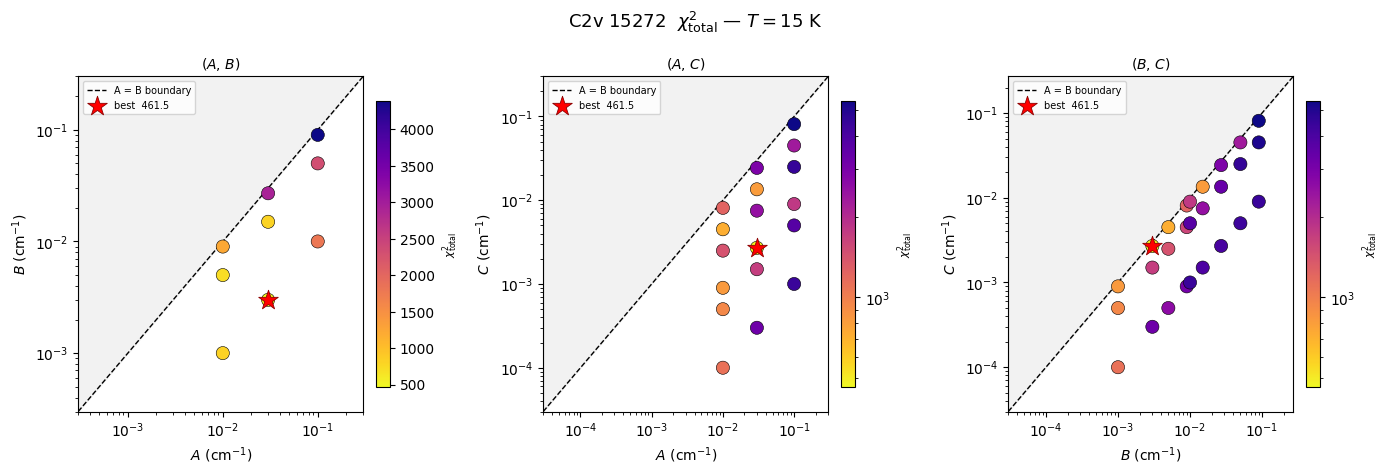

In [13]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

plot_chi2 = 'all'


def _norm(chi2):
    vmin, vmax = np.nanmin(chi2), np.nanmax(chi2)
    if vmax / max(vmin, 1e-30) > 10:
        return mcolors.LogNorm(vmin=vmin, vmax=vmax)
    return mcolors.Normalize(vmin=vmin, vmax=vmax)


def _add_forbidden(ax, x, y):
    """Shade the forbidden region y >= x on log-log axes."""
    lo = min(x.min(), y.min()) * 0.3
    hi = max(x.max(), y.max()) * 3
    diag = np.logspace(np.log10(lo), np.log10(hi), 400)
    ax.plot(diag, diag, 'k--', lw=1, zorder=2, label='A = B boundary')
    ax.fill_between(diag, diag, hi * 10, color='gray', alpha=0.10, zorder=1)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)


def plot_row(axes, A, B, C, chi2, chi2_label, cmap='plasma_r'):
    norm = _norm(chi2)
    good = np.isfinite(chi2)
    pairs = [
        (axes[0], A, B, r'$A$ (cm$^{-1}$)', r'$B$ (cm$^{-1}$)', '($A$, $B$)'),
        (axes[1], A, C, r'$A$ (cm$^{-1}$)', r'$C$ (cm$^{-1}$)', '($A$, $C$)'),
        (axes[2], B, C, r'$B$ (cm$^{-1}$)', r'$C$ (cm$^{-1}$)', '($B$, $C$)'),
    ]
    scatters = []
    for ax, x, y, xl, yl, title in pairs:
        _add_forbidden(ax, x[good], y[good])

        sc = ax.scatter(x[good], y[good], c=chi2[good], cmap=cmap, norm=norm,
                        s=90, edgecolors='k', linewidths=0.4, zorder=3)
        scatters.append(sc)

        ibest = np.nanargmin(chi2)
        ax.scatter(x[ibest], y[ibest], marker='*', s=220, c='red',
                   edgecolors='darkred', linewidths=0.6, zorder=5,
                   label=f'best  {chi2[ibest]:.1f}')

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(xl, fontsize=10)
        ax.set_ylabel(yl, fontsize=10)
        ax.set_title(title, fontsize=10)
        ax.legend(fontsize=7, loc='upper left')
        cb = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
        cb.set_label(chi2_label, fontsize=8)
    return scatters

def _marginal_min(x, y, chi2):
    """Return unique (x, y) pairs with minimum chi2 over the third dimension."""
    # Use rounded log-values as keys to handle float precision
    best = {}
    for xi, yi, c in zip(x, y, chi2):
        if not np.isfinite(c):
            continue
        key = (round(np.log10(xi), 8), round(np.log10(yi), 8))
        if key not in best or c < best[key][2]:
            best[key] = (xi, yi, c)
    vals = np.array(list(best.values()))
    return vals[:, 0], vals[:, 1], vals[:, 2]


def plot_row(axes, A, B, C, chi2, chi2_label, cmap='plasma_r'):
    projections = [
        (axes[0], A, B, r'$A$ (cm$^{-1}$)', r'$B$ (cm$^{-1}$)', '($A$, $B$)'),
        (axes[1], A, C, r'$A$ (cm$^{-1}$)', r'$C$ (cm$^{-1}$)', '($A$, $C$)'),
        (axes[2], B, C, r'$B$ (cm$^{-1}$)', r'$C$ (cm$^{-1}$)', '($B$, $C$)'),
    ]
    scatters = []
    for ax, x_all, y_all, xl, yl, title in projections:
        # Marginalize over the third constant: keep min chi2 at each (x, y) pair
        x, y, c2 = _marginal_min(x_all, y_all, chi2)
        norm = _norm(c2)

        _add_forbidden(ax, x, y)

        sc = ax.scatter(x, y, c=c2, cmap=cmap, norm=norm,
                        s=90, edgecolors='k', linewidths=0.4, zorder=3)
        scatters.append(sc)

        ibest = np.argmin(c2)
        ax.scatter(x[ibest], y[ibest], marker='*', s=220, c='red',
                   edgecolors='darkred', linewidths=0.6, zorder=5,
                   label=f'best  {c2[ibest]:.1f}')

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(xl, fontsize=10)
        ax.set_ylabel(yl, fontsize=10)
        ax.set_title(title, fontsize=10)
        ax.legend(fontsize=7, loc='upper left')
        cb = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
        cb.set_label(chi2_label, fontsize=8)
    return scatters




T = 15
load_npz_name = 'grid_search_C2v_15272.npz'
d = np.load(load_npz_name)
plot_chi2 = 'total'
savefig = False

T_arr   = d['T']
A_arr   = d['A']
Bf_arr  = d['Bf']
Cf_arr  = d['Cf']
c2_dir  = d['chi2_direct']
c2_dT   = d['chi2_dT']
c2_tot  = d['chi2_total']

B_arr = Bf_arr * A_arr
C_arr = Cf_arr * B_arr

T_vals = np.unique(T_arr)
if T is None:
    T_pick = T_vals[0]
    print(f"No --T supplied; using T = {T_pick:.0f} K.  "
          f"Available: {T_vals.tolist()}")
else:
    T_pick = T_vals[np.argmin(np.abs(T_vals - T))]
    print(f"Using T = {T_pick:.0f} K")

mask = T_arr == T_pick
A, B, C = A_arr[mask], B_arr[mask], C_arr[mask]
sets = {
    'direct': (c2_dir[mask],  r'$\chi^2_\mathrm{direct}$'),
    'dT':     (c2_dT[mask],   r'$\chi^2_\mathrm{dT}$'),
    'total':  (c2_tot[mask],  r'$\chi^2_\mathrm{total}$'),
}

if plot_chi2 == 'all':
    keys = ['direct', 'dT', 'total']
    fig, axes = plt.subplots(3, 3, figsize=(14, 13))
    fig.suptitle(f'C2v 15272 — $T = {T_pick:.0f}$ K', fontsize=13, y=1.01)
    for row, key in enumerate(keys):
        chi2, lbl = sets[key]
        plot_row(axes[row], A, B, C, chi2, lbl)
else:
    chi2, lbl = sets[plot_chi2]
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
    fig.suptitle(f'C2v 15272  {lbl} — $T = {T_pick:.0f}$ K', fontsize=13)
    plot_row(axes, A, B, C, chi2, lbl)

plt.tight_layout()
tag = f'T{T_pick:.0f}_{plot_chi2}'
out = str(REPO_ROOT + f'/figs/chi2_landscape_C2v_15272_{tag}.png')
if savefig:
    plt.savefig(out, dpi=200, bbox_inches='tight')
    print(f'Saved {out}')
plt.show()
